# This is the tutorial notebook, welcome !
#### We start by importing the libraries and the data

In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader, random_split

from plots import *
from utils import *
from dataset import *

In [3]:
data_path = 'cope_data/ssp585_time_series.pkl' # Change this to your data path

with open(data_path, 'rb') as f:
    cope_data = pkl.load(f)

## Exploring the data
#### We describe here how the data is organized.

In [4]:
print('Cope data is a nested disctionary with climate models as keys and runs as sub-keys.')

climate_models = list(cope_data.keys())
print(f'Cope data has {len(climate_models)} climate models. First five climate models: {climate_models[0:5]}')
print()

runs_of_first_model = list(cope_data['ICON-ESM-LR'].keys())
print(f'First climate model has {len(runs_of_first_model)} runs: {runs_of_first_model}')

data_of_first_run_of_first_model = cope_data['ICON-ESM-LR']['r1i1p1f1']
print(f'First run of first climate model is a numpy array of shape {data_of_first_run_of_first_model.shape} where {data_of_first_run_of_first_model.shape[0]} is the number of timesteps, {data_of_first_run_of_first_model.shape[1]} is the number of latitudes and {data_of_first_run_of_first_model.shape[2]} is the number of longitudes.')
print()

runs_per_model = [len(cope_data[mod]) for mod in cope_data.keys()]
total_number_of_runs = sum(runs_per_model)
print(f'Total number of runs across all models : {total_number_of_runs}')
print(f'Average number of experiments per model : {total_number_of_runs/len(climate_models)}')
print()


Cope data is a nested disctionary with climate models as keys and runs as sub-keys.
Cope data has 72 climate models. First five climate models: ['ICON-ESM-LR', 'EC-Earth3', 'EC-Earth3-Veg-LR', 'FIO-ESM-2-0', 'CMCC-CM2-SR5']

First climate model has 5 runs: ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1', 'r5i1p1f1']
First run of first climate model is a numpy array of shape (165, 72, 144) where 165 is the number of timesteps, 72 is the number of latitudes and 144 is the number of longitudes.

Total number of runs across all models : 784
Average number of experiments per model : 10.88888888888889



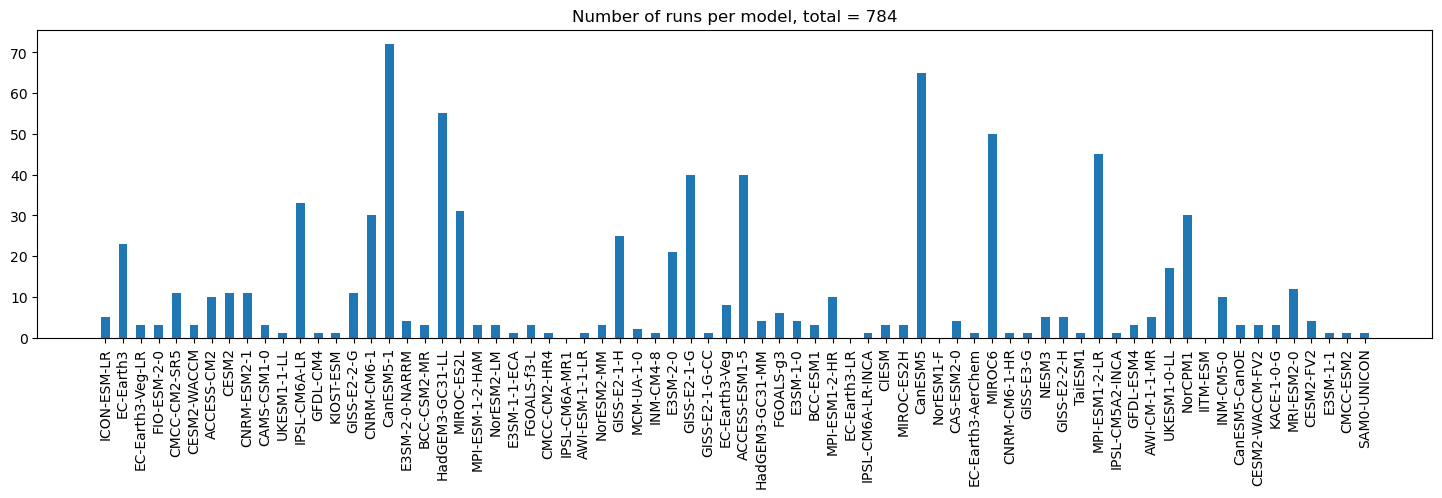

In [5]:
plot_histogram_runs(cope_data)

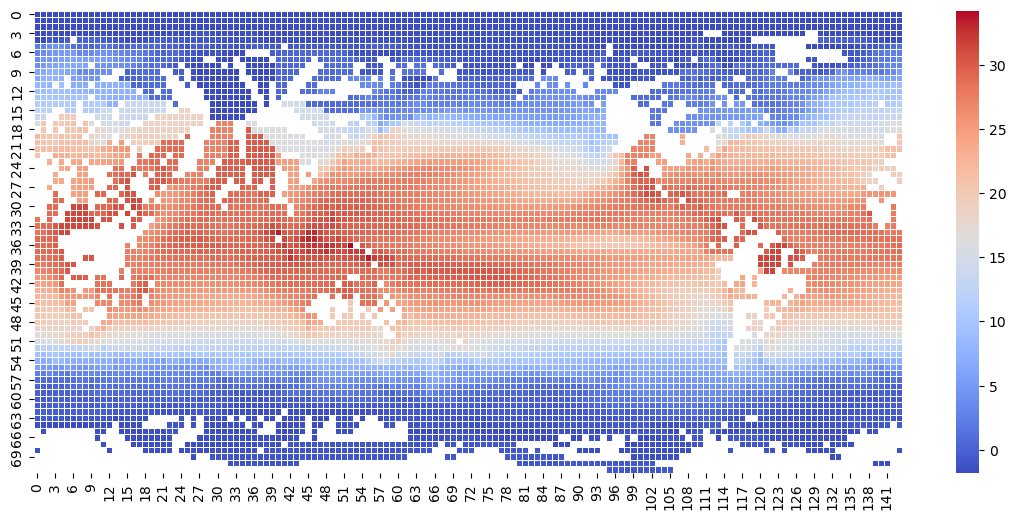

In [6]:
plot_heatmap(cope_data, model='ICON-ESM-LR', run='r1i1p1f1', year=1980)

## Preprocessing
The data is a bit messy, so we need to preprocess it. 
We first take out the models with less than five runs, we keep the latitudes under 60° degree and we also downscale the data to have less cells.


In [7]:
prune(cope_data, min_runs=5) # Remove runs with less than 5 years of data

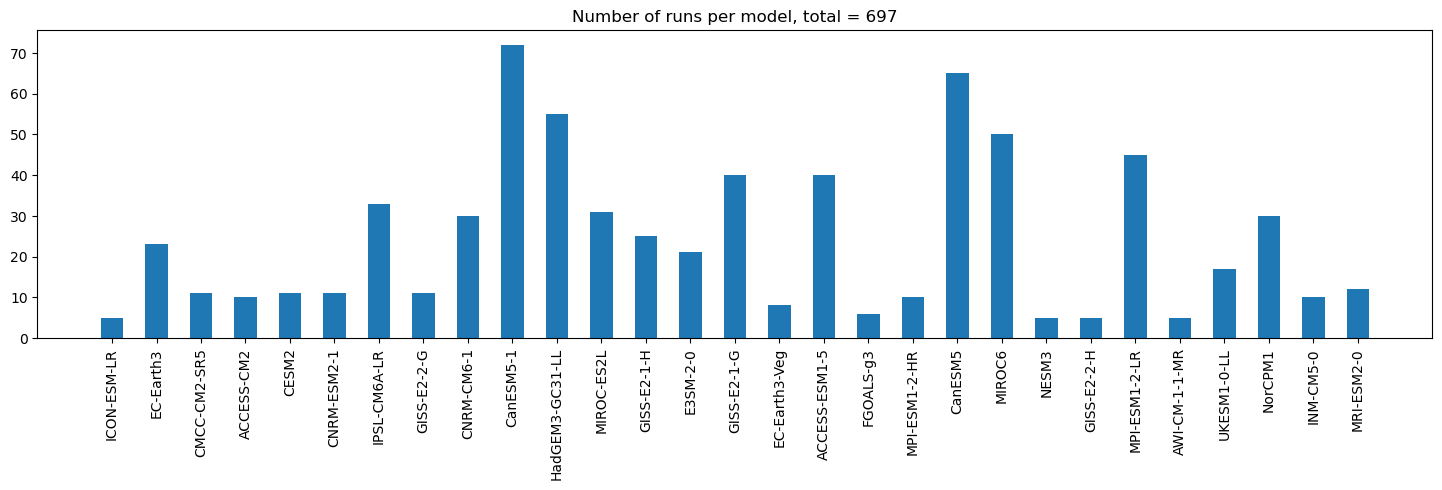

In [8]:
plot_histogram_runs(cope_data)

In [9]:
cut_lat(cope_data, max_lat=60) # Cut latitude to a maximum of 60 degrees
downscale(cope_data) # Downscale the data to a lower resolution

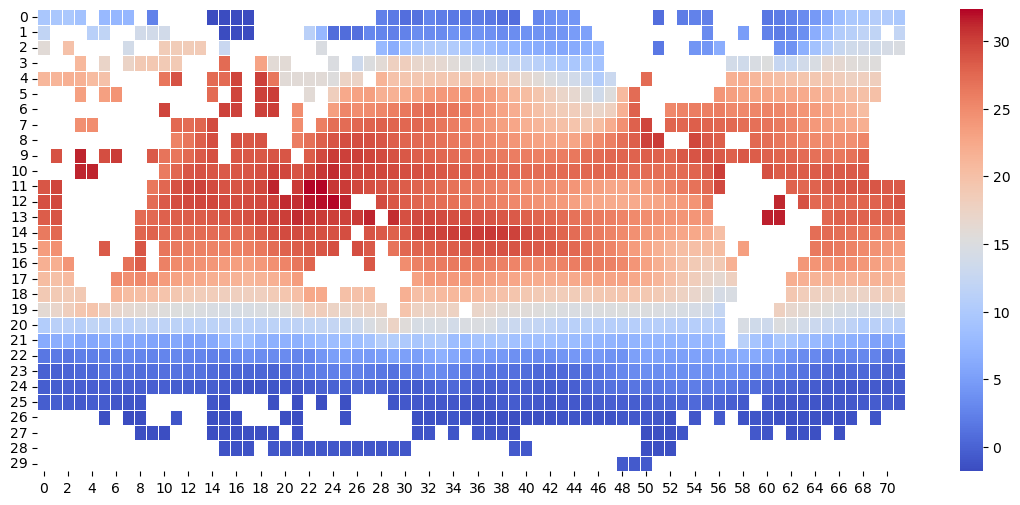

In [10]:
plot_heatmap(cope_data, model='ICON-ESM-LR', run='r1i1p1f1', year=1980)

We find the biggest possible mask of nans and we use it to set every grid to the same mask. 

In [11]:
union_nan_mask = find_union_nan_mask(cope_data) # Find the union of NaN masks across all variables
inpute(cope_data, union_nan_mask) # Inpute missing values using the union NaN mask

We also restrict the timesteps, using only data from 1980 to 2013.

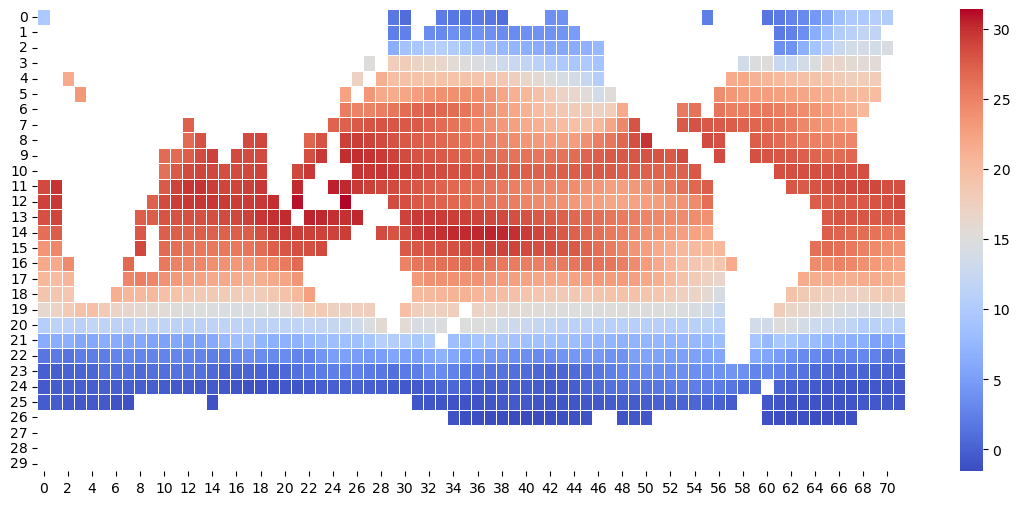

In [12]:
plot_heatmap(cope_data, model='ICON-ESM-LR', run='r1i1p1f1', year=1980)

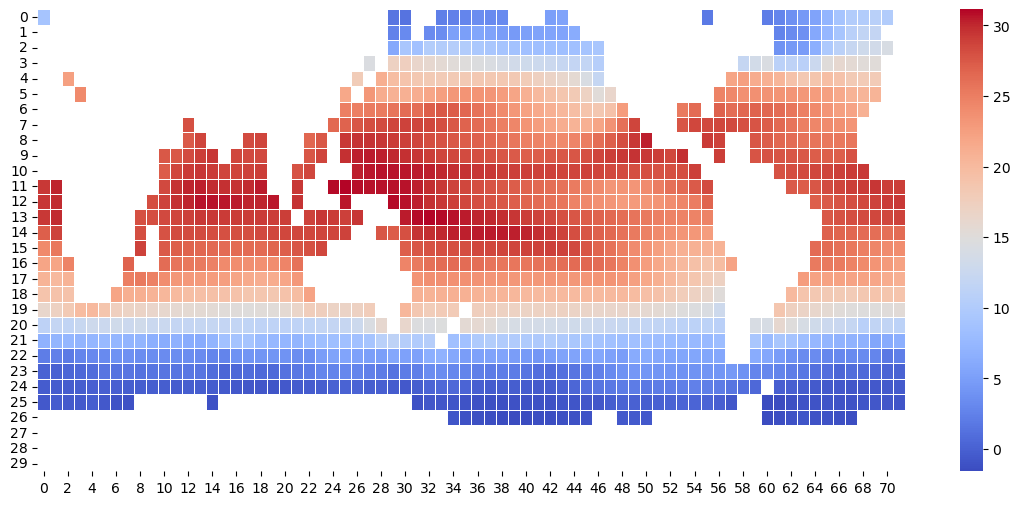

In [13]:
plot_heatmap(cope_data, model='ICON-ESM-LR', run='r1i1p1f1', year=2013)

## Normalization

We now plot the timeseries of the CanESM5-1 model in the cell (20, 50) along with the mean forced response timeserie.

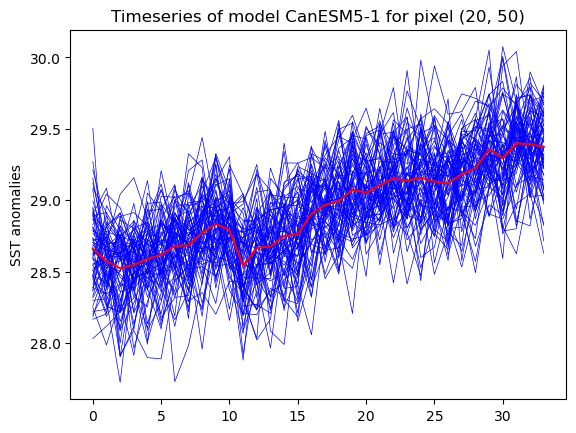

In [16]:
plot_timeseries(cope_data, model='CanESM5-1', pixel=(20, 50))

The formula to compute the mean of the runs is the following, where $i$ is the run, $p$ is the pixel, $m$ is the model and $t$ is the timestep

$$x^p_{i, t, m} = \frac{1}{T}\sum_{t}{\frac{1}{I}\sum_{i}{x^p_{i, t, m}}}$$

Notice that we compute the mean across the runs but across the time too. If we fix the pixel and the model, we get a single value.

To get the standard deviation we compute the std across the runs and then take the mean. We then have that the normalized timeserie is

$$\text{normalized timeserie} = (\text{timeserie} - \text{mean}) / \text{std}$$

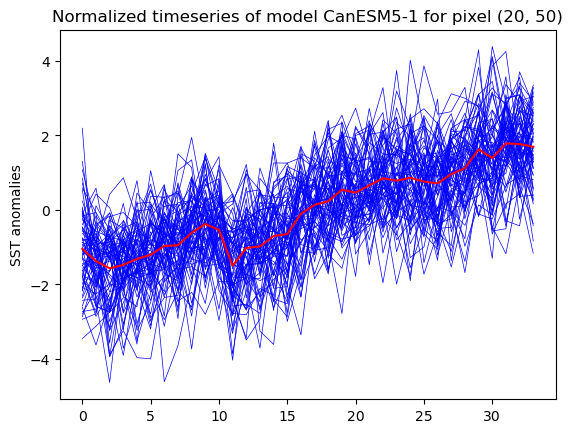

In [21]:
plot_normalized_timeseries(cope_data, model='CanESM5-1', pixel=(20, 50))

Another normalising option would be to compute the mean just across the runs, having a normalized timeserie that resembles this : 

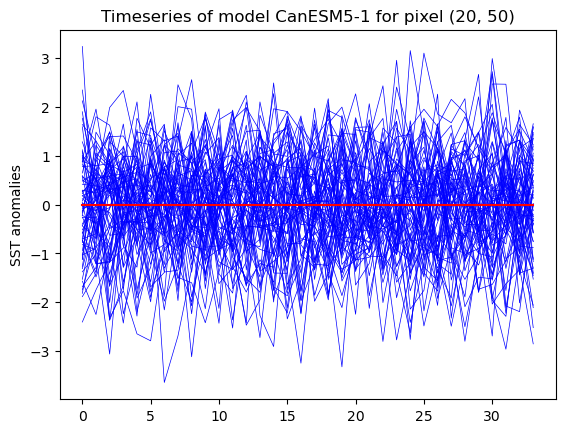

In [22]:
plot_normalized_timeseries_other(cope_data, model='CanESM5-1', pixel=(20, 50))

Throughout the rest of this project, we normalize the timeseries according to the first strategy.

## 1. Reduced Rank Regression

In [ ]:
from regression import Ridge

X_train, y_train, X_test, y_test = extract_per_grid(cope_data, union_nan_mask)

print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}') # (timesteps*runs, cells that are not NaNs)

X_train shape: (23413, 1308), y_train shape: (23413, 1308)
X_test shape: (170, 1308), y_test shape: (170, 1308)


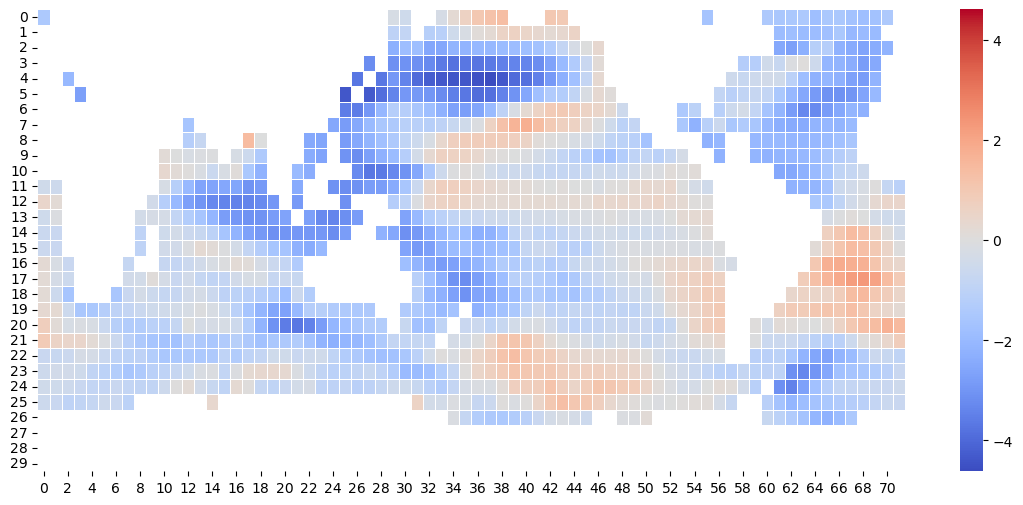

In [72]:
plot_grid(X_train[0], union_nan_mask, flip=True)

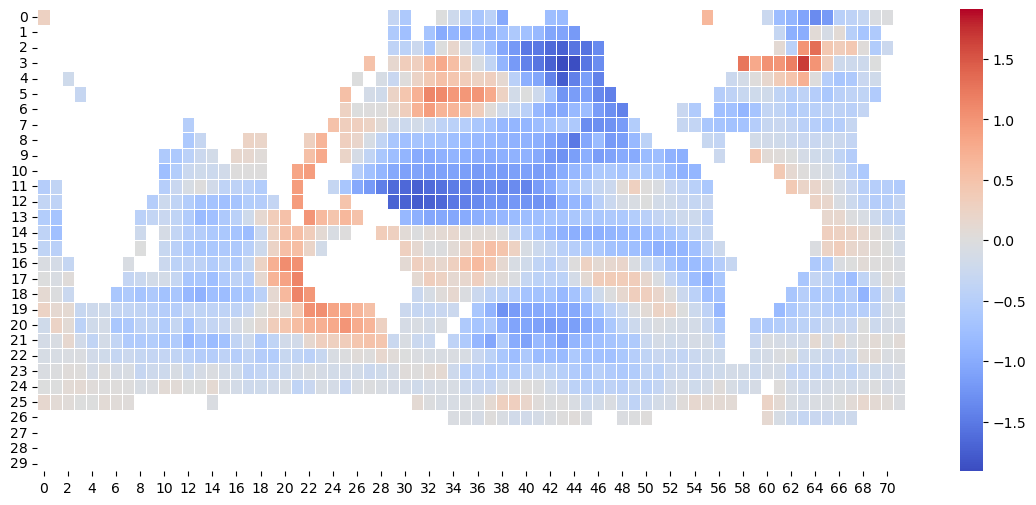

In [73]:
plot_grid(X_test[0], union_nan_mask, flip=True)

In [68]:
X_train, y_train = torch.tensor(X_train), torch.tensor(y_train)
X_test, y_test = torch.tensor(X_test), torch.tensor(y_test)

C:\Users\mirco\AppData\Local\Temp\ipykernel_17636\1038633355.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train, y_train = torch.tensor(X_train), torch.tensor(y_train)
C:\Users\mirco\AppData\Local\Temp\ipykernel_17636\1038633355.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test, y_test = torch.tensor(X_test), torch.tensor(y_test)


rank of W : 924, shape : torch.Size([1309, 1308])


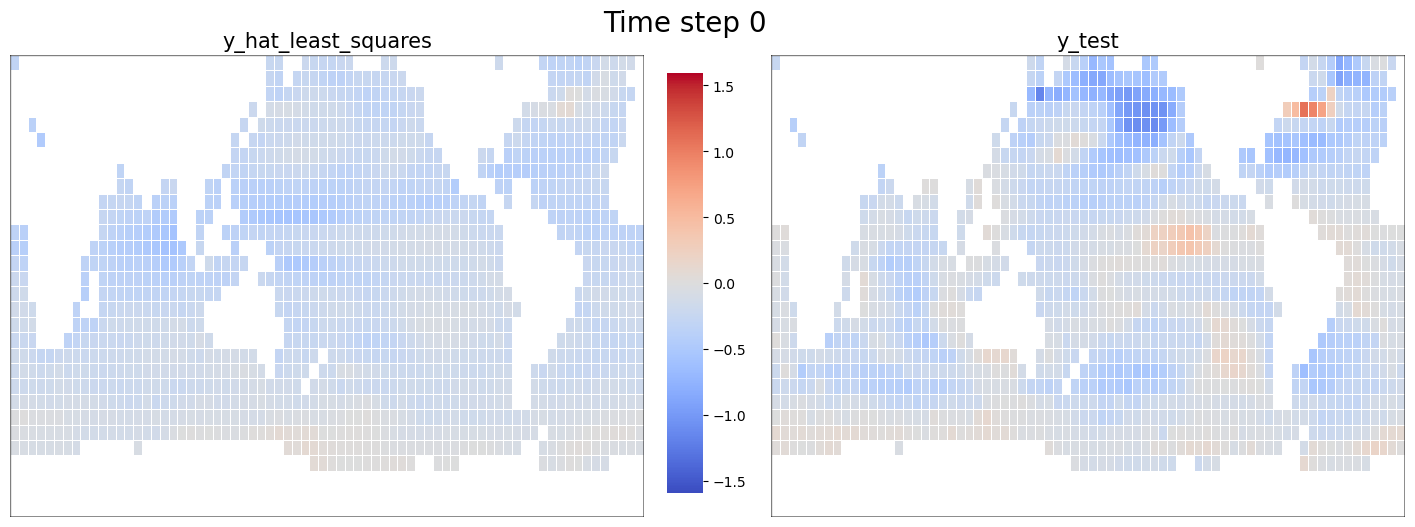

In [ ]:
least_squares_model = Ridge() # Initialize least squares regression model
least_squares_model.fit(X_train, y_train)

W_least_squares = least_squares_model.W
print(f"rank of W : {torch.linalg.matrix_rank(W_least_squares)}, shape : {W_least_squares.shape}")

y_hat_least_squares = least_squares_model.predict(X_test)

animation = get_duo_animated_timeserie(y_hat_least_squares[:34], y_test[:34], union_nan_mask, left_title='y_hat_least_squares', right_title='y_test', flattened=False)
animation.save('animations/least_squares.gif', writer='pillow', fps=1)

rank of W : 924, shape : torch.Size([1309, 1308])


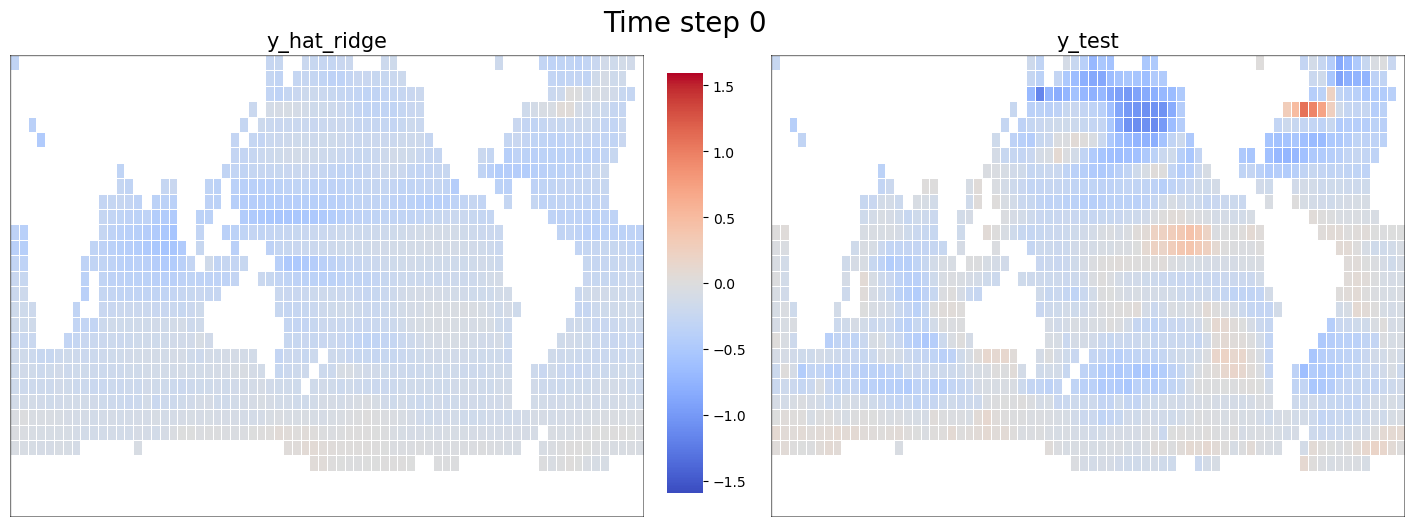

In [79]:
ridge_model = Ridge(lambda_=100) # Initialize ridge regression model
ridge_model.fit(X_train, y_train)

W_ridge = ridge_model.W
print(f"rank of W : {torch.linalg.matrix_rank(W_ridge)}, shape : {W_ridge.shape}")

y_hat_ridge = ridge_model.predict(X_test)

animation = get_duo_animated_timeserie(y_hat_ridge[:34], y_test[:34], union_nan_mask, left_title='y_hat_ridge', right_title='y_test', flattened=False)
animation.save('animations/ridge.gif', writer='pillow', fps=1)

rank of W : 50, shape : torch.Size([1309, 1308])


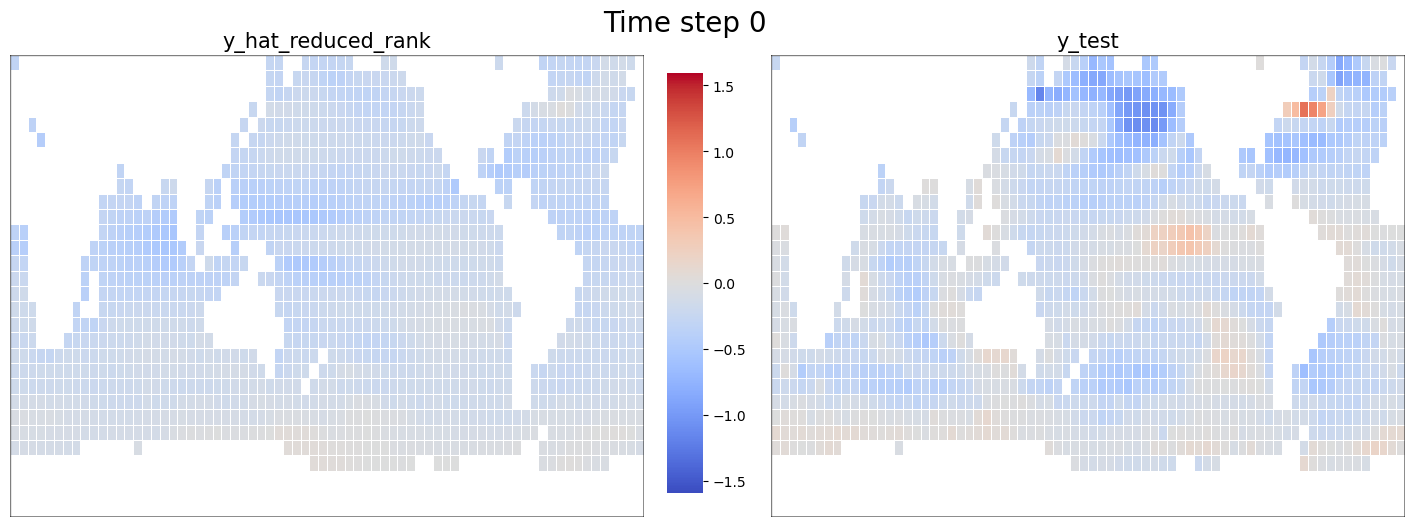

In [80]:
reduced_rank_model = Ridge(lambda_=100, rank=50) # Initialize reduced rank regression model
reduced_rank_model.fit(X_train, y_train)

W_reduced_rank = reduced_rank_model.W
print(f"rank of W : {torch.linalg.matrix_rank(W_reduced_rank)}, shape : {W_reduced_rank.shape}")

y_hat_reduced_rank = reduced_rank_model.predict(X_test)

animation = get_duo_animated_timeserie(y_hat_reduced_rank[:34], y_test[:34], union_nan_mask, left_title='y_hat_reduced_rank', right_title='y_test', flattened=False)
animation.save('animations/reduced_rank.gif', writer='pillow', fps=1)

## 2. VAEs

In [82]:
from vae import basic_VAE, VAE

X_train, y_train, X_test, y_test = extract_per_timeserie(cope_data, union_nan_mask)

print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}') # (runs, timesteps*cells that are not NaNs)

X_train shape: (607, 44472), y_train shape: (607, 44472)
X_test shape: (5, 44472), y_test shape: (5, 44472)


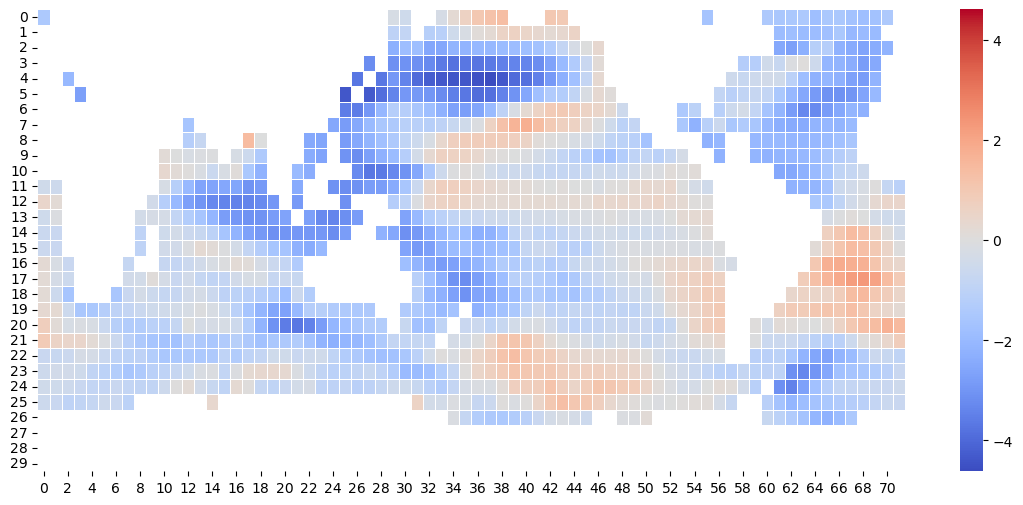

In [86]:
first_train_timegrid = from_flat_to_timegrid(X_train[0], union_nan_mask) # (timesteps, latitudes, longitudes)
plot_grid(first_train_timegrid[0], union_nan_mask)

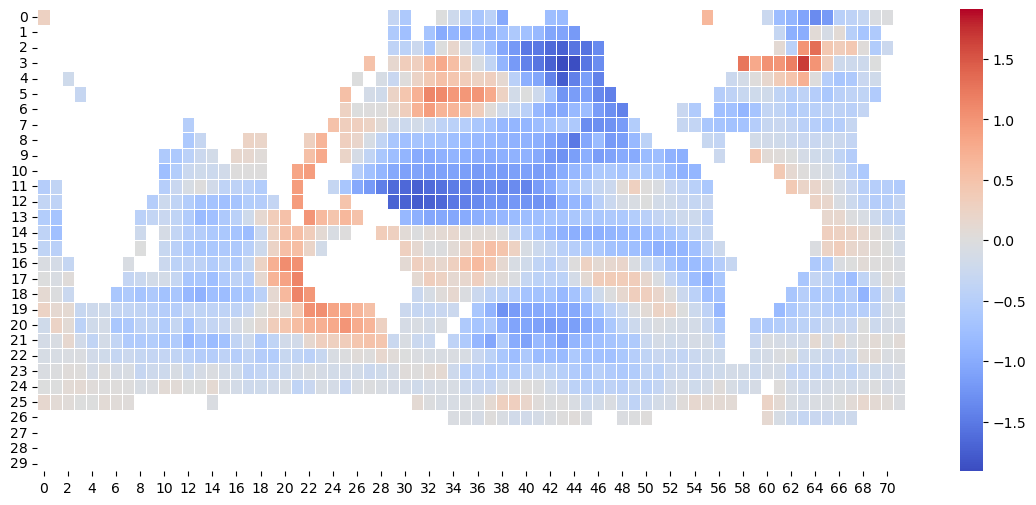

In [87]:
first_test_timegrid = from_flat_to_timegrid(X_test[0], union_nan_mask) # (timesteps, latitudes, longitudes)
plot_grid(first_test_timegrid[0], union_nan_mask)

### Basic VAE

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

batch_size = 16

train_dataset = CopeDataset(samples=X_train, labels=y_train)
test_dataset = CopeDataset(samples=X_test, labels=y_test)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [91]:
lr = 1.5e-3
epochs = 30

basic_vae_model = basic_VAE(input_dim=44472, hidden_dim=500, latent_dim=100).to(device) # Initialize the basic VAE model
optimizer = torch.optim.Adam(basic_vae_model.parameters(), lr=lr)

print("Start training basic VAE...")
basic_vae_model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, y) in enumerate(train_dataloader):
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mean, logvar = basic_vae_model(x)
        loss = basic_vae_model.loss(x_hat, y, mean, logvar)
        
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("Epoch", epoch + 1, "complete !", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

Start training basic VAE...
Epoch 1 complete ! 	Average Loss:  153109.1671373522
Epoch 2 complete ! 	Average Loss:  8685.195220122467
Epoch 3 complete ! 	Average Loss:  7833.638803842905
Epoch 4 complete ! 	Average Loss:  7521.565693623311
Epoch 5 complete ! 	Average Loss:  7359.890822951858
Epoch 6 complete ! 	Average Loss:  7246.9459855363175
Epoch 7 complete ! 	Average Loss:  7180.087006440034
Epoch 8 complete ! 	Average Loss:  7084.2519003378375
Epoch 9 complete ! 	Average Loss:  6997.061417863176
Epoch 10 complete ! 	Average Loss:  6916.539999472128
Epoch 11 complete ! 	Average Loss:  6870.575393264358
Epoch 12 complete ! 	Average Loss:  6774.163930532095
Epoch 13 complete ! 	Average Loss:  6684.306112753378
Epoch 14 complete ! 	Average Loss:  6600.926111169763
Epoch 15 complete ! 	Average Loss:  6531.845082875845
Epoch 16 complete ! 	Average Loss:  6436.852407094595
Epoch 17 complete ! 	Average Loss:  6336.753299197635
Epoch 18 complete ! 	Average Loss:  6272.869279191301
Epoch 1

In [92]:
basic_vae_model.eval()

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)
        x_hat, _, _ = basic_vae_model(x)
        x_hat.detach()
        break

x, x_hat, y = x.numpy()[0], x_hat.numpy()[0], y.numpy()[0]

print(f'x shape: {x.shape}, x_hat shape: {x_hat.shape}, y shape: {y.shape}')

x shape: (44472,), x_hat shape: (44472,), y shape: (44472,)


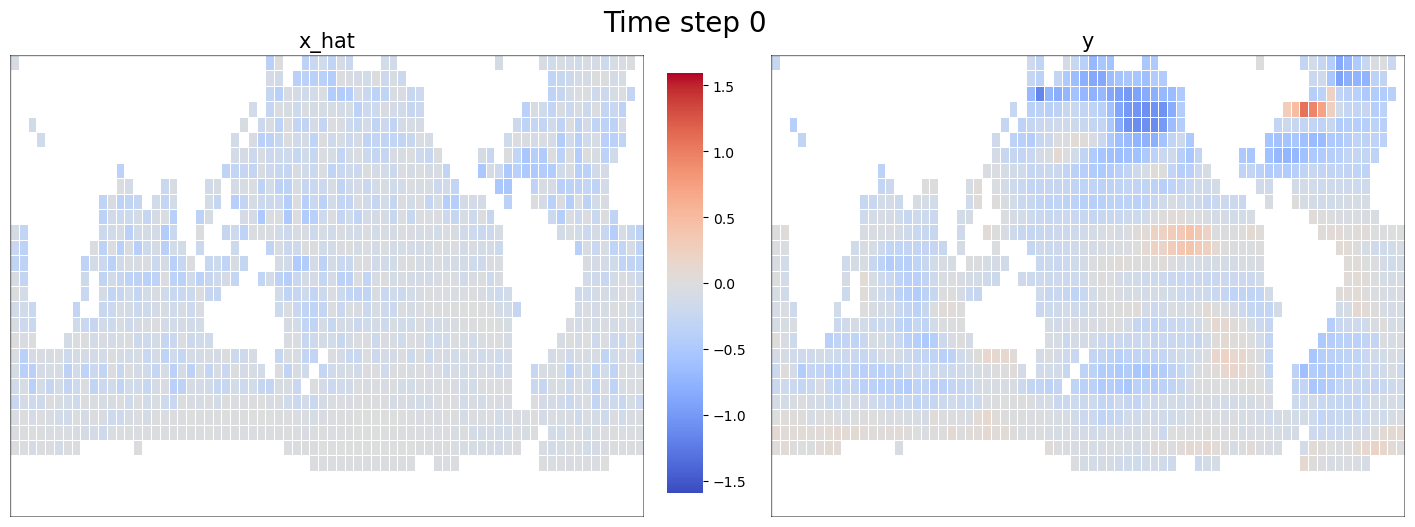

In [93]:
d = get_duo_animated_timeserie(x_hat, y, union_nan_mask, left_title='x_hat', right_title='y')
d.save('animations/basic_vae_x_hat_y.gif', writer='pillow', fps=1)

In [ ]:
a = get_animated_timeserie(x, union_nan_mask)
a.save('animations/basic_vae_x.gif', writer='pillow', fps=1)

b = get_animated_timeserie(x_hat, union_nan_mask)
b.save('animations/basic_vae_x_hat.gif', writer='pillow', fps=1)

c = get_animated_timeserie(y, union_nan_mask)
c.save('animations/basic_vae_y.gif', writer='pillow', fps=1)

### VAE

In [94]:
lr = 1.5e-3
epochs = 30

vae_model = VAE(input_dim=44472, hidden_dim=500, latent_dim=100).to(device) # Initialize the VAE model with a more complex architecture
optimizer = torch.optim.Adam(vae_model.parameters(), lr=lr)

print("Start training VAE...")
vae_model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, y) in enumerate(train_dataloader):
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mean, var = vae_model(x)
        loss = vae_model.loss(x_hat, y, mean, var)
        
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("Epoch", epoch + 1, "complete !", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

Start training VAE...
Epoch 1 complete ! 	Average Loss:  29264.80417282517
Epoch 2 complete ! 	Average Loss:  4919.669756915118
Epoch 3 complete ! 	Average Loss:  4455.607065561655
Epoch 4 complete ! 	Average Loss:  4226.475559543919
Epoch 5 complete ! 	Average Loss:  3774.8386890308275
Epoch 6 complete ! 	Average Loss:  2874.8140671188767
Epoch 7 complete ! 	Average Loss:  2306.9386811127533
Epoch 8 complete ! 	Average Loss:  2008.3392630912163
Epoch 9 complete ! 	Average Loss:  1879.5676071579392
Epoch 10 complete ! 	Average Loss:  1766.767894847973
Epoch 11 complete ! 	Average Loss:  1723.2883729676942
Epoch 12 complete ! 	Average Loss:  1646.7818801467483
Epoch 13 complete ! 	Average Loss:  1630.0793028135558
Epoch 14 complete ! 	Average Loss:  1621.0118243243244
Epoch 15 complete ! 	Average Loss:  1601.5393000422298
Epoch 16 complete ! 	Average Loss:  1595.2783599028717
Epoch 17 complete ! 	Average Loss:  1558.7535053974873
Epoch 18 complete ! 	Average Loss:  1537.903707968222
Epo

In [95]:
vae_model.eval()

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)
        x_hat, _, _ = vae_model(x)
        x_hat.detach()
        break

x, x_hat, y = x.numpy()[0], x_hat.numpy()[0], y.numpy()[0]

print(f'x shape: {x.shape}, x_hat shape: {x_hat.shape}, y shape: {y.shape}')

x shape: (44472,), x_hat shape: (44472,), y shape: (44472,)


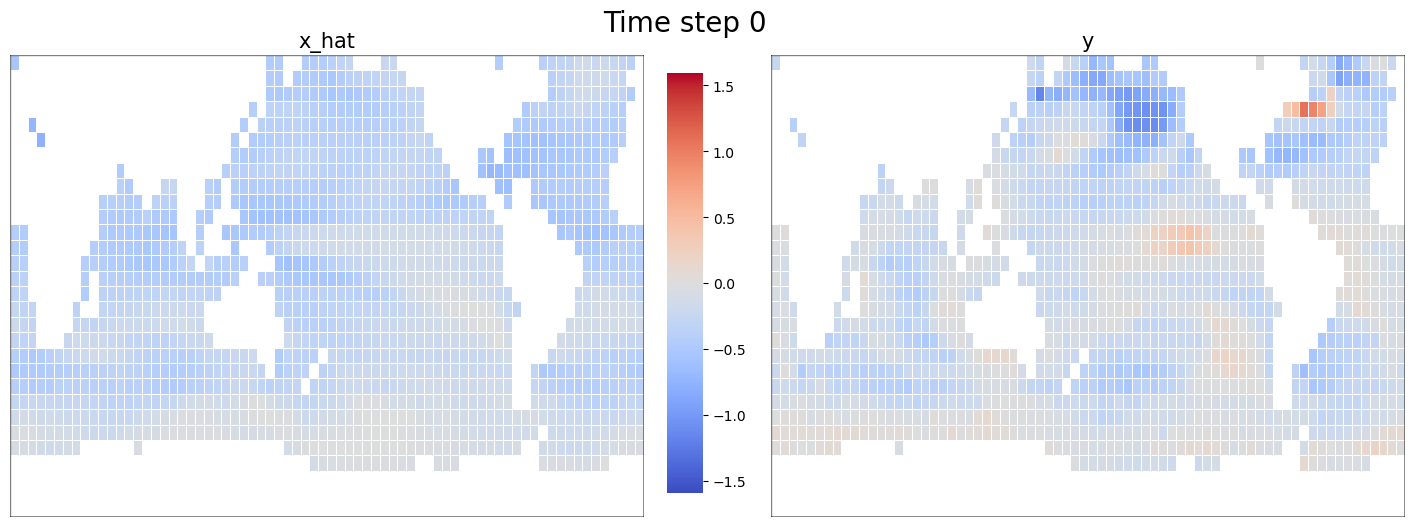

In [96]:
d = get_duo_animated_timeserie(x_hat, y, union_nan_mask, left_title='x_hat', right_title='y')
d.save('animations/vae_x_hat_y.gif', writer='pillow', fps=1)

In [ ]:
a = get_animated_timeserie(x, union_nan_mask)
a.save('animations/vae_x.gif', writer='pillow', fps=1)

b = get_animated_timeserie(x_hat, union_nan_mask)
b.save('animations/vae_x_hat.gif', writer='pillow', fps=1)

c = get_animated_timeserie(y, union_nan_mask)
c.save('animations/vae_y.gif', writer='pillow', fps=1)

#### Confidence interval

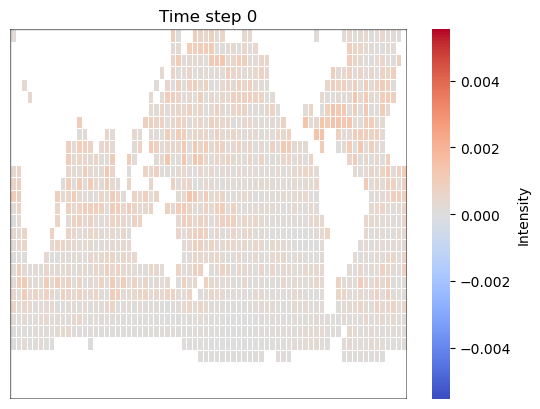

In [97]:
n_samples = 100

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)[0]
        samples = basic_vae_model.sample(x, n_samples)
        break

conf_int = get_confidence_interval_grid_timeserie(samples)

a = get_animated_timeserie(conf_int, union_nan_mask)
a.save('animations/basic_vae_conf_int.gif', writer='pillow', fps=1)

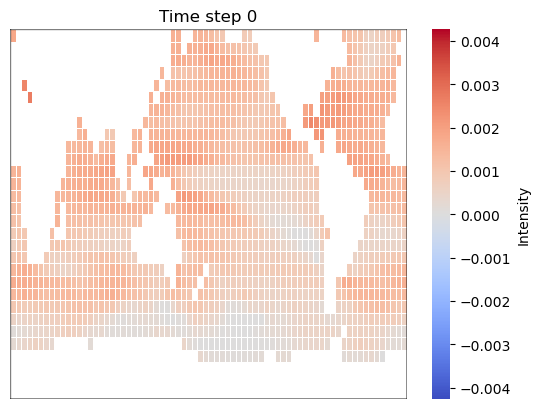

In [98]:
n_samples = 100

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)[0]
        samples = vae_model.sample(x, n_samples)
        break

conf_int = get_confidence_interval_grid_timeserie(samples)

a = get_animated_timeserie(conf_int, union_nan_mask)
a.save('animations/vae_conf_int.gif', writer='pillow', fps=1)

## 3. Convolutional VAE

In [ ]:
from vae import CVAE

X_train, y_train, X_test, y_test = extract_per_images(cope_data, union_nan_mask)

print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}') # (runs, timesteps, latitudes, longitudes)

X_train shape: (607, 34, 30, 72), y_train shape: (607, 34, 30, 72)
X_test shape: (5, 34, 30, 72), y_test shape: (5, 34, 30, 72)


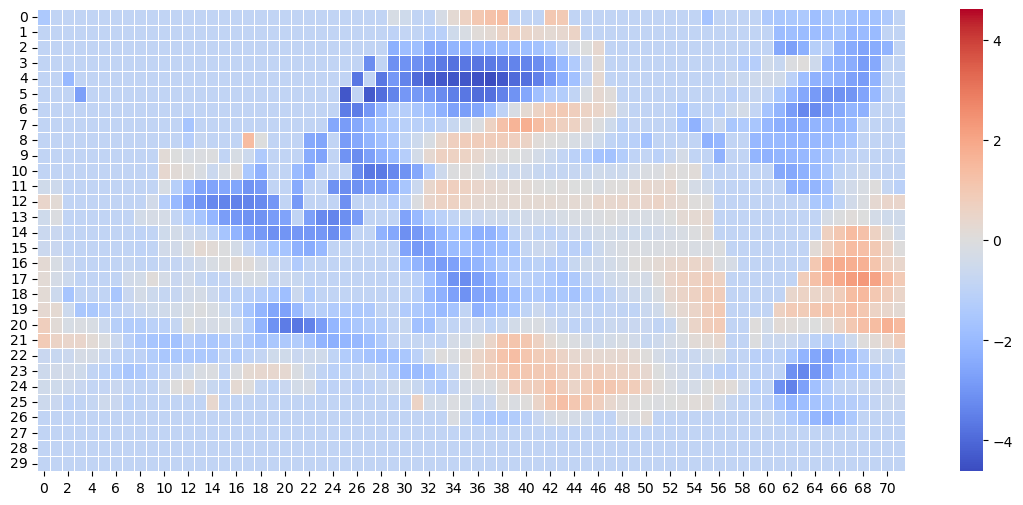

In [113]:
plot_grid(X_train[0][0], union_nan_mask)

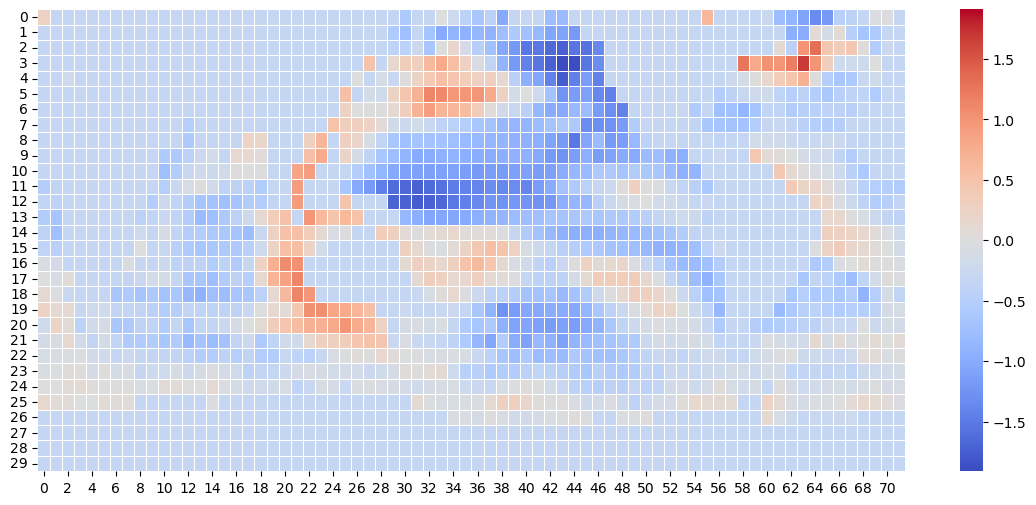

In [114]:
plot_grid(X_test[0][0], union_nan_mask)

In [115]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

batch_size = 16

train_dataset = CopeDataset(samples=X_train, labels=y_train)
test_dataset = CopeDataset(samples=X_test, labels=y_test)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

Using device: cpu


In [116]:
lr = 1.5e-3
epochs = 50

cvae_model = CVAE(mask=union_nan_mask, in_channels=34, hidden_dims=[68, 136], latent_dim=100).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

print("Start training CVAE...")
cvae_model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, y) in enumerate(train_dataloader):
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mean, var = cvae_model(x)
        loss = cvae_model.loss(x_hat, y, mean, var)
        
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("Epoch", epoch + 1, "complete !", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

Start training CVAE...
Epoch 1 complete ! 	Average Loss:  5488.561107738598
Epoch 2 complete ! 	Average Loss:  4407.109018686655
Epoch 3 complete ! 	Average Loss:  4209.422640413852
Epoch 4 complete ! 	Average Loss:  3437.20959802576
Epoch 5 complete ! 	Average Loss:  2494.7869543127113
Epoch 6 complete ! 	Average Loss:  1995.7165296399914
Epoch 7 complete ! 	Average Loss:  1780.0623515361065
Epoch 8 complete ! 	Average Loss:  1675.2730267498944
Epoch 9 complete ! 	Average Loss:  1599.799290012669
Epoch 10 complete ! 	Average Loss:  1539.4355072846283
Epoch 11 complete ! 	Average Loss:  1534.2730910842483
Epoch 12 complete ! 	Average Loss:  1525.5213293127113
Epoch 13 complete ! 	Average Loss:  1529.1690310916385
Epoch 14 complete ! 	Average Loss:  1537.9376517630913
Epoch 15 complete ! 	Average Loss:  1496.8114096151817
Epoch 16 complete ! 	Average Loss:  1434.5672277502113
Epoch 17 complete ! 	Average Loss:  1395.2586010082348
Epoch 18 complete ! 	Average Loss:  1363.3338161159206
Ep

In [ ]:
cvae_model.eval()

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)
        x_hat, _, _ = cvae_model(x)
        x_hat.detach()

        break

x, x_hat, y = x.numpy()[0], x_hat.numpy()[0], y.numpy()[0]

print(f'x shape: {x.shape}, x_hat shape: {x_hat.shape}, y shape: {y.shape}')

x shape: (34, 30, 72), x_hat shape: (34, 30, 72), y shape: (34, 30, 72)


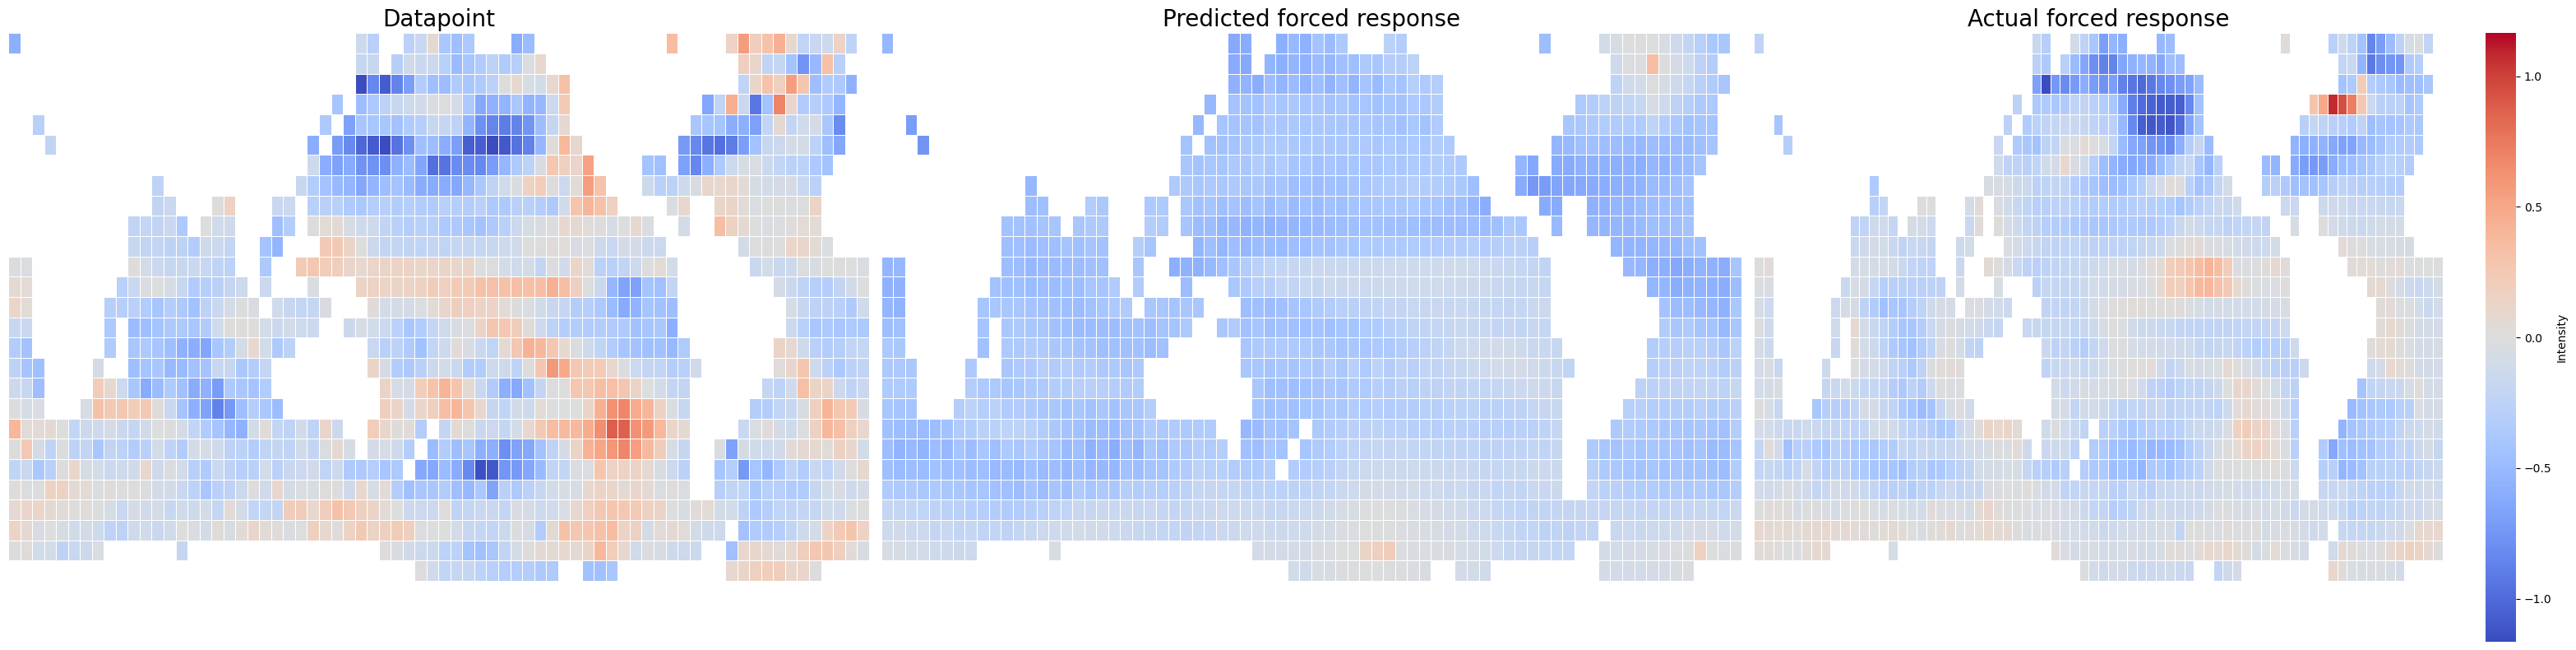

In [119]:
x = fill_grid_timeserie(x, union_nan_mask, method='value', fill_value=np.nan)
x_hat = fill_grid_timeserie(x_hat, union_nan_mask, method='value', fill_value=np.nan)
y = fill_grid_timeserie(y, union_nan_mask, method='value', fill_value=np.nan)

plot_trio_grids(x[0], x_hat[0], y[0], union_nan_mask)

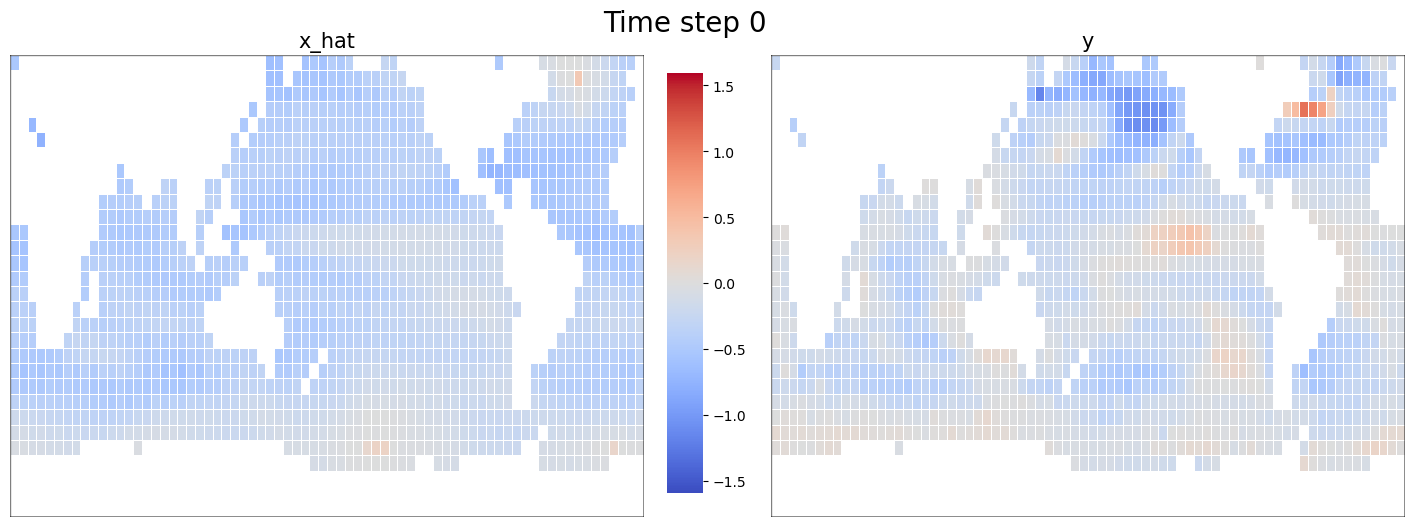

In [121]:
d = get_duo_animated_timeserie(x_hat, y, union_nan_mask, left_title='x_hat', right_title='y', flattened=False)
d.save('animations/cvae_x_hat_y.gif', writer='pillow', fps=1)

In [ ]:
a = get_animated_timeserie(x, union_nan_mask)
a.save('animations/cvae_x.gif', writer='pillow', fps=1)

b = get_animated_timeserie(x_hat, union_nan_mask)
b.save('animations/cvae_x_hat.gif', writer='pillow', fps=1)

c = get_animated_timeserie(y, union_nan_mask)
c.save('animations/cvae_y.gif', writer='pillow', fps=1)

#### Confidence interval

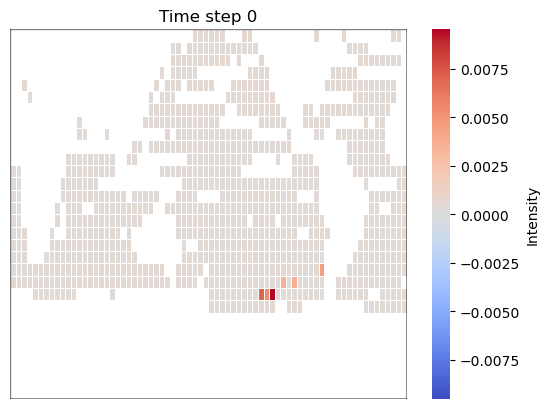

In [ ]:
n_samples = 100

cvae_model.eval()
with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)[0]
        samples = cvae_model.sample(x, n_samples)
        break

conf_int = get_confidence_interval_grid_timeserie(samples)
conf_int = fill_grid_timeserie(conf_int, union_nan_mask, method='value', fill_value=np.nan)

a = get_animated_timeserie(conf_int, union_nan_mask)
a.save('animations/cvae_conf_int.gif', writer='pillow', fps=1)